# Assignment 8: Custom Timeseries Forecasting

## Summary

In this notebook, I generate a custom timeseries of the form:

$$y(t) = A(t) \cdot \cos(\omega t) + \text{noise}$$

where:
- **A(t) = 1 + 0.5 · sin(0.01t)** — a slowly oscillating amplitude envelope
- **ω = 0.3** — the angular frequency of the cosine carrier
- **noise** — Gaussian noise with standard deviation 0.1

I then apply two forecasting methods from Chapter 13 of *Deep Learning with Python*:
1. **Dense (fully connected) model** — flattens the input window and uses dense layers
2. **LSTM model** — uses a recurrent layer to capture temporal patterns

Both models are trained to predict the next value in the timeseries given a window of past values. Results are compared using Mean Absolute Error (MAE).

In [1]:
%pip install keras keras-hub --upgrade -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import keras
from keras import layers
import matplotlib.pyplot as plt

## Generate Custom Timeseries

Generate y(t) = A(t) · cos(ωt) + noise with A(t) = 1 + 0.5·sin(0.01t) and ω = 0.3.

Generated 5000 data points
A(t) = 1 + 0.5 * sin(0.01 * t)
w = 0.3


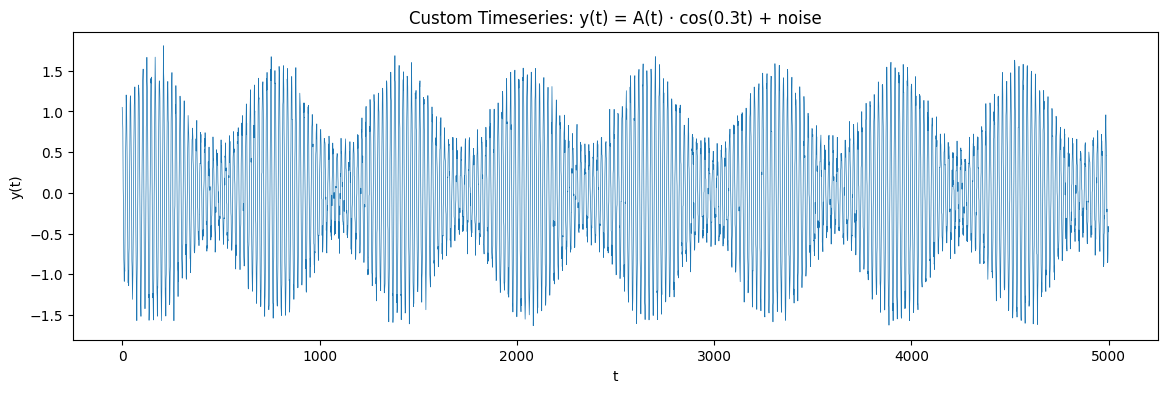

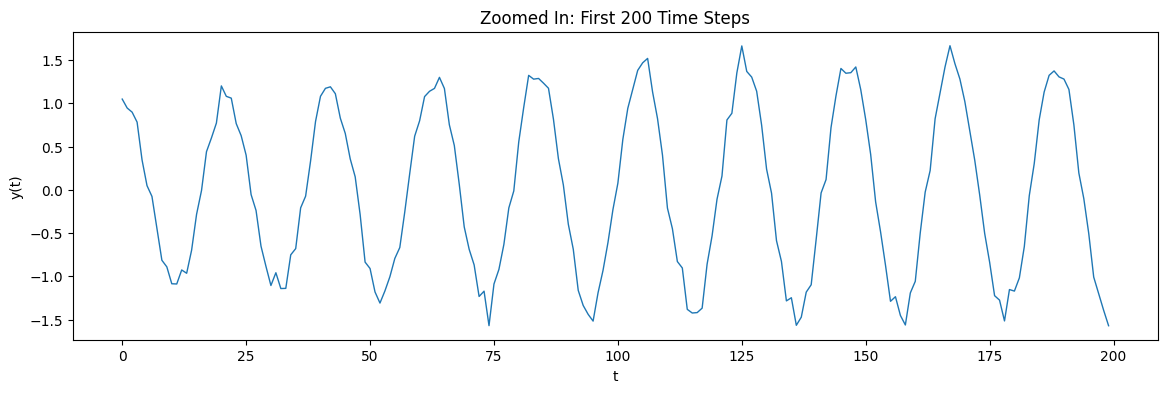

In [3]:
np.random.seed(42)

num_points = 5000
t = np.arange(num_points, dtype=np.float32)

# Custom timeseries: y(t) = A(t) * cos(w * t) + noise
A_t = 1 + 0.5 * np.sin(0.01 * t)       # slowly varying amplitude
w = 0.3                                   # angular frequency
noise = np.random.normal(0, 0.1, size=num_points).astype(np.float32)

y = A_t * np.cos(w * t) + noise
y = y.astype(np.float32)

print(f"Generated {num_points} data points")
print(f"A(t) = 1 + 0.5 * sin(0.01 * t)")
print(f"w = {w}")

# Plot full timeseries
plt.figure(figsize=(14, 4))
plt.plot(t, y, linewidth=0.5)
plt.title("Custom Timeseries: y(t) = A(t) · cos(0.3t) + noise")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.show()

# Plot a zoomed-in window
plt.figure(figsize=(14, 4))
plt.plot(t[:200], y[:200], linewidth=1.0)
plt.title("Zoomed In: First 200 Time Steps")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.show()

## Prepare Data

Split into 50% train, 25% validation, 25% test. Normalize and create windowed datasets.

In [4]:
# Train/val/test split
num_train = int(0.5 * num_points)
num_val = int(0.25 * num_points)
num_test = num_points - num_train - num_val
print(f"Train: {num_train}, Val: {num_val}, Test: {num_test}")

# Normalize using training set statistics
mean_y = y[:num_train].mean()
std_y = y[:num_train].std()
y_normalized = (y - mean_y) / std_y

# Reshape for timeseries_dataset_from_array (needs 2D input)
data = y_normalized.reshape(-1, 1)

# Windowed dataset parameters
sequence_length = 50
delay = sequence_length  # predict the next value after the window
batch_size = 64

train_dataset = keras.utils.timeseries_dataset_from_array(
    data[:-delay],
    targets=y_normalized[delay:],
    sequence_length=sequence_length,
    batch_size=batch_size,
    shuffle=True,
    start_index=0,
    end_index=num_train,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    data[:-delay],
    targets=y_normalized[delay:],
    sequence_length=sequence_length,
    batch_size=batch_size,
    shuffle=True,
    start_index=num_train,
    end_index=num_train + num_val,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    data[:-delay],
    targets=y_normalized[delay:],
    sequence_length=sequence_length,
    batch_size=batch_size,
    shuffle=False,
    start_index=num_train + num_val,
)

for samples, targets in train_dataset:
    print("Input shape:", samples.shape)
    print("Target shape:", targets.shape)
    break

Train: 2500, Val: 1250, Test: 1250
Input shape: (64, 50, 1)
Target shape: (64,)


## Method 1: Dense (Fully Connected) Model

A simple baseline that flattens the input window and uses dense layers, from Chapter 13.

In [5]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
dense_model = keras.Model(inputs, outputs)

dense_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
dense_model.summary()

callbacks = [
    keras.callbacks.ModelCheckpoint("dense_model.keras", save_best_only=True)
]

dense_history = dense_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=callbacks,
)

dense_model = keras.models.load_model("dense_model.keras")
dense_test_results = dense_model.evaluate(test_dataset)
print(f"\nDense Model - Test MAE: {dense_test_results[1]:.4f}")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3150 - mae: 0.4116 - val_loss: 0.0952 - val_mae: 0.2475
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0774 - mae: 0.2225 - val_loss: 0.0772 - val_mae: 0.2239
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0664 - mae: 0.2062 - val_loss: 0.0716 - val_mae: 0.2148
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0602 - mae: 0.1962 - val_loss: 0.0664 - val_mae: 0.2077
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0560 - mae: 0.1894 - val_loss: 0.0628 - val_mae: 0.2015
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0529 - mae: 0.1835 - val_loss: 0.0614 - val_mae: 0.2000
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0509 - mae: 0.1804 - val_loss: 0.0590 - val_mae: 0.1956
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0487 - mae: 0.1766 - val_loss: 0.0580 - val_mae: 0.1929
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0474 - mae: 

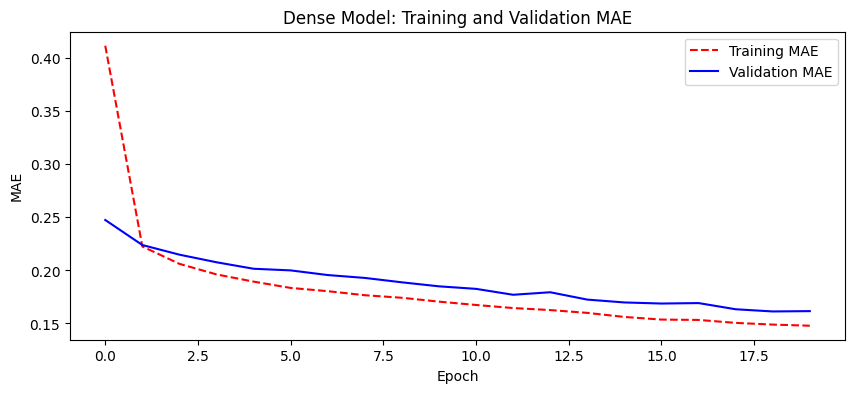

In [6]:
# Plot Dense model training curves
plt.figure(figsize=(10, 4))
plt.plot(dense_history.history["mae"], "r--", label="Training MAE")
plt.plot(dense_history.history["val_mae"], "b", label="Validation MAE")
plt.title("Dense Model: Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

## Method 2: LSTM Model

An LSTM recurrent model that can learn temporal dependencies in the timeseries, from Chapter 13.

In [7]:
inputs = keras.Input(shape=(sequence_length, 1))
x = layers.LSTM(32)(inputs)
outputs = layers.Dense(1)(x)
lstm_model = keras.Model(inputs, outputs)

lstm_model.compile(optimizer="adam", loss="mse", metrics=["mae"])
lstm_model.summary()

callbacks = [
    keras.callbacks.ModelCheckpoint("lstm_model.keras", save_best_only=True)
]

lstm_history = lstm_model.fit(
    train_dataset,
    epochs=20,
    validation_data=val_dataset,
    callbacks=callbacks,
)

lstm_model = keras.models.load_model("lstm_model.keras")
lstm_test_results = lstm_model.evaluate(test_dataset)
print(f"\nLSTM Model - Test MAE: {lstm_test_results[1]:.4f}")

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 50, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.6262 - mae: 0.6435 - val_loss: 0.1481 - val_mae: 0.2983
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0627 - mae: 0.1992 - val_loss: 0.0460 - val_mae: 0.1711
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0369 - mae: 0.1551 - val_loss: 0.0356 - val_mae: 0.1533
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0309 - mae: 0.1412 - val_loss: 0.0312 - val_mae: 0.1430
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0270 - mae: 0.1311 - val_loss: 0.0273 - val_mae: 0.1334
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0244 - mae: 0.1248 - val_loss: 0.0265 - val_mae: 0.1307
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0232 - mae: 0.1215 - val_loss: 0.0247 - val_mae: 0.1260
Epoch 8/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0224 - mae: 0.1192 - val_loss: 0.0240 - val_mae: 0.1246
Epoch 9/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0218 - mae: 

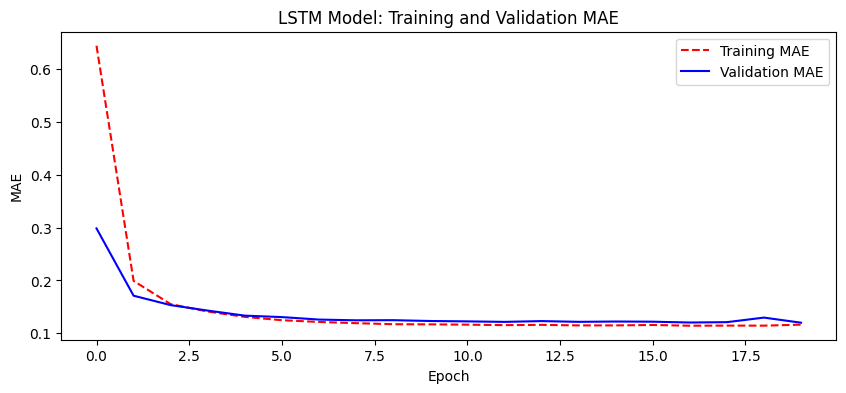

In [8]:
# Plot LSTM model training curves
plt.figure(figsize=(10, 4))
plt.plot(lstm_history.history["mae"], "r--", label="Training MAE")
plt.plot(lstm_history.history["val_mae"], "b", label="Validation MAE")
plt.title("LSTM Model: Training and Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.show()

## Results Comparison

In [9]:
print("=" * 40)
print("Model Comparison (Test MAE)")
print("=" * 40)
print(f"Dense Model:  {dense_test_results[1]:.4f}")
print(f"LSTM Model:   {lstm_test_results[1]:.4f}")
print("=" * 40)

if lstm_test_results[1] < dense_test_results[1]:
    print("LSTM outperforms the Dense model.")
else:
    print("Dense model outperforms or matches the LSTM model.")

Model Comparison (Test MAE)
Dense Model:  0.1492
LSTM Model:   0.1149
LSTM outperforms the Dense model.
